In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

data_dir = Path('./data')
output_dir = Path('./results')
output_dir.mkdir(exist_ok=True)

start_kst = pd.Timestamp('2022-01-01', tz='Asia/Seoul')
end_kst = pd.Timestamp('2024-01-01', tz='Asia/Seoul')


## 지원 데이터 그룹 확인



In [ ]:
user_groups = pd.read_csv(
    data_dir / 'user_group.csv',
    usecols=['user_uuid', 'user_group'],
    dtype='string',
    encoding='utf-8-sig'
)
user_groups['user_uuid'] = user_groups['user_uuid'].str.strip()
user_groups['user_group'] = user_groups['user_group'].str.strip()

assert user_groups[['user_uuid', 'user_group']].notna().all().all()
assert user_groups['user_uuid'].is_unique

applications = pd.read_csv(
    data_dir / 'Application.csv',
    usecols=['application_uuid', 'user_uuid', 'job_uuid', 'company_uuid', 'cdate'],
    dtype='string',
    encoding='utf-8-sig'
).drop_duplicates()

applications['application_at_kst'] = pd.to_datetime(
    applications['cdate'], errors='coerce', utc=True
).dt.tz_convert('Asia/Seoul')
applications = applications[
    applications['application_at_kst'].ge(start_kst)
    & applications['application_at_kst'].lt(end_kst)
].copy()

assert applications[['application_uuid', 'user_uuid', 'job_uuid']].notna().all().all()
assert applications['application_uuid'].is_unique
assert set(applications['user_uuid']) == set(user_groups['user_uuid'])

comparison_users = user_groups[
    user_groups['user_group'].isin(['G0_신호없음', 'G3_고중첩신호'])
].copy()
comparison_users['group_code'] = comparison_users['user_group'].map({
    'G0_신호없음': 'G0',
    'G3_고중첩신호': 'G3'
})

print('전체 지원 건수:', len(applications))
print('전체 지원 유저 수:', applications['user_uuid'].nunique())
print('\n비교할 그룹별 유저 수')
print(comparison_users['group_code'].value_counts().sort_index().to_string())


전체 지원 건수: 92526
전체 지원 유저 수: 10287

비교할 그룹별 유저 수
group_code
G0    8362
G3     104


## 공고 정보와 북마크 연결

공고는 job_uuid로 연결하고, 북마크는 user_uuid와 job_uuid를 함께 사용한다. 같은 공고라도 다른 유저의 북마크가 섞이지 않도록 두 ID가 모두 일치하는 행만 연결한다.


분석 기간 밖의 북마크는 포함하지 않는다. 따라서 북마크 없이 지원했다는 결과에는 기간 이전에 북마크한 경우도 섞일 수 있다. 공고별 북마크는 이 데이터에서 유저와 공고 조합당 한 행인지 확인하고 사용한다.


In [ ]:
jobs = pd.read_csv(
    data_dir / 'Job.csv',
    usecols=['job_uuid', 'job_field', 'career_type_string'],
    dtype='string',
    encoding='utf-8-sig'
)
assert jobs['job_uuid'].is_unique
jobs['has_job_record'] = True

bookmarks = pd.read_csv(
    data_dir / 'JobBookmark.csv',
    usecols=['user_uuid', 'job_uuid', 'cdate'],
    dtype='string',
    encoding='utf-8-sig'
).drop_duplicates()

bookmarks['bookmark_at_kst'] = pd.to_datetime(
    bookmarks['cdate'], errors='coerce', utc=True
).dt.tz_convert('Asia/Seoul')
bookmarks = bookmarks[
    bookmarks['bookmark_at_kst'].ge(start_kst)
    & bookmarks['bookmark_at_kst'].lt(end_kst)
    & bookmarks['user_uuid'].isin(user_groups['user_uuid'])
].copy()
assert not bookmarks.duplicated(['user_uuid', 'job_uuid']).any()

application_table = applications.merge(
    jobs, on='job_uuid', how='left', validate='many_to_one'
)
application_table = application_table.merge(
    bookmarks[['user_uuid', 'job_uuid', 'bookmark_at_kst']],
    on=['user_uuid', 'job_uuid'],
    how='left',
    validate='many_to_one'
)
assert len(application_table) == len(applications)

comparison_applications = application_table[
    application_table['user_uuid'].isin(comparison_users['user_uuid'])
].copy()

print('공고 정보가 없는 지원:', application_table['has_job_record'].isna().sum())
print('직무 정보가 있는 지원:', application_table['job_field'].notna().sum())
print('기간 내 북마크가 연결된 지원:', application_table['bookmark_at_kst'].notna().sum())
print('G0과 G3의 지원 건수:', len(comparison_applications))


공고 정보가 없는 지원: 1120
직무 정보가 있는 지원: 91406
기간 내 북마크가 연결된 지원: 10670
G0과 G3의 지원 건수: 49452


## 유저별 지원 행동 계산

- 새벽 지원: 한국시간 00:00부터 05:59까지의 지원
- 주말 지원: 토요일 또는 일요일의 지원
- 신입 허용: 공고의 경력 조건에 '신입'이 포함된 지원. 지원자 본인의 경력을 뜻하지 않음.
- 북마크 후 지원: 같은 공고의 북마크 시각이 지원 시각보다 이르거나 같은 경우

경력 조건을 알 수 없는 지원은 신입 허용 비율의 분모에서 제외. 북마크가 연결되지 않은 지원은 북마크 후 지원에 포함하지 않음.

반복 지원 비율은 (지원 건수 - 고유 공고 수) / 지원 건수 

하루 평균 지원 수는 지원한 날짜만 분모에 넣는다.


In [ ]:
comparison_applications['application_date'] = (
    comparison_applications['application_at_kst'].dt.date
)
comparison_applications['night_application'] = (
    comparison_applications['application_at_kst'].dt.hour.between(0, 5)
)
comparison_applications['weekend_application'] = (
    comparison_applications['application_at_kst'].dt.dayofweek >= 5
)
comparison_applications['bookmark_before_application'] = (
    comparison_applications['bookmark_at_kst']
    <= comparison_applications['application_at_kst']
)
comparison_applications['entry_allowed'] = (
    comparison_applications['career_type_string']
    .str.contains('신입', na=False)
    .astype(float)
)
comparison_applications.loc[
    comparison_applications['career_type_string'].isna(), 'entry_allowed'
] = float('nan')

user_application_features = comparison_applications.groupby('user_uuid').agg(
    application_count=('application_uuid', 'count'),
    unique_job_count=('job_uuid', 'nunique'),
    application_active_days=('application_date', 'nunique'),
    night_application_pct=('night_application', 'mean'),
    weekend_application_pct=('weekend_application', 'mean'),
    entry_allowed_pct=('entry_allowed', 'mean'),
    bookmark_before_application_pct=('bookmark_before_application', 'mean')
).reset_index()

application_rate_columns = [
    'night_application_pct', 'weekend_application_pct',
    'entry_allowed_pct', 'bookmark_before_application_pct'
]
user_application_features[application_rate_columns] *= 100
user_application_features['applications_per_active_day'] = (
    user_application_features['application_count']
    / user_application_features['application_active_days']
)
user_application_features['repeat_application_pct'] = (
    (user_application_features['application_count']
     - user_application_features['unique_job_count'])
    / user_application_features['application_count'] * 100
)


## 지원 간격과 북마크 수 계산

지원 시각을 유저별로 정렬한 뒤 diff로 바로 이전 지원과의 시간 차이를 구한다. 초를 60으로 나누어 분 단위로 바꾸고, 유저마다 간격의 중앙값을 남긴다. 한 번만 지원한 유저는 간격을 계산할 수 없으므로 결측값으로 둔다.

북마크 수에는 지원하지 않은 공고의 북마크도 포함한다. 북마크 기록이 없는 유저만 0건으로 채운다. 지원 간격과 경력 조건처럼 알 수 없는 값은 0으로 바꾸지 않는다.


In [ ]:
sorted_applications = comparison_applications.sort_values(
    ['user_uuid', 'application_at_kst']
).copy()
sorted_applications['application_gap_min'] = (
    sorted_applications.groupby('user_uuid')['application_at_kst']
    .diff().dt.total_seconds() / 60
)
user_application_gaps = (
    sorted_applications.groupby('user_uuid')['application_gap_min']
    .median().reset_index(name='median_application_gap_min')
)
user_bookmark_features = (
    bookmarks.groupby('user_uuid').size().reset_index(name='bookmark_count')
)

user_behavior_features = comparison_users.merge(
    user_application_features, on='user_uuid', how='left', validate='one_to_one'
)
user_behavior_features = user_behavior_features.merge(
    user_application_gaps, on='user_uuid', how='left', validate='one_to_one'
)
user_behavior_features = user_behavior_features.merge(
    user_bookmark_features, on='user_uuid', how='left', validate='one_to_one'
)
user_behavior_features['bookmark_count'] = (
    user_behavior_features['bookmark_count'].fillna(0).astype(int)
)

print('유저별 행동표:', len(user_behavior_features), '행')
display(user_behavior_features.head())


유저별 행동표: 8466 행


,user_uuid,user_group,group_code,application_count,unique_job_count,application_active_days,night_application_pct,weekend_application_pct,entry_allowed_pct,bookmark_before_application_pct,applications_per_active_day,repeat_application_pct,median_application_gap_min,bookmark_count
0,24ffac10-a46e-4adb-af66-0074d259c809,G0_신호없음,G0,2,2,2,0.0,0.0,100.000000,100.0,1.000000,0.0,280976.866667,10
1,3e20b9ee-48bc-46cd-9713-d629f0a51b59,G0_신호없음,G0,1,1,1,100.0,0.0,0.000000,0.0,1.000000,0.0,NaN,0
2,2bc97037-032e-4137-93d4-feebaa1c2524,G0_신호없음,G0,1,1,1,0.0,0.0,0.000000,0.0,1.000000,0.0,NaN,10
3,b7694073-cd02-4250-a9e7-ecb5b67a27f7,G0_신호없음,G0,1,1,1,0.0,0.0,0.000000,0.0,1.000000,0.0,NaN,0
4,8155b95a-66f6-4b46-a7a5-49b38daf30c7,G0_신호없음,G0,8,8,6,0.0,0.0,14.285714,0.0,1.333333,0.0,8629.033333,2


## 로그 데이터 정리



In [ ]:
log_parts = []
raw_log_count = 0

for filename in ['log_2022.csv', 'log_2023.csv']:
    filtered_log_count = 0

    for chunk in pd.read_csv(
        data_dir / filename,
        usecols=['user_uuid', 'URL', 'timestamp', 'date', 'response_code', 'method'],
        dtype='string',
        encoding='utf-8-sig',
        chunksize=200000
    ):
        raw_log_count += len(chunk)
        chunk = chunk.dropna(subset=['URL']).copy()
        valid_date = chunk['date'].fillna('').str.match(r'^\d{4}-\d{2}-\d{2}$')
        chunk = chunk[valid_date].copy()

        for column in ['user_uuid', 'URL', 'method', 'response_code']:
            chunk[column] = chunk[column].str.strip()

        chunk = chunk[
            chunk['user_uuid'].isin(comparison_users['user_uuid'])
        ].copy()
        chunk['log_at_kst'] = pd.to_datetime(
            chunk['timestamp'].str.replace(' UTC', '', regex=False),
            format='ISO8601', errors='coerce', utc=True
        ).dt.tz_convert('Asia/Seoul')
        chunk['response_code'] = pd.to_numeric(
            chunk['response_code'], errors='coerce'
        )

        chunk = chunk[
            chunk['log_at_kst'].ge(start_kst)
            & chunk['log_at_kst'].lt(end_kst)
            & chunk['response_code'].between(200, 299)
        ].copy()
        filtered_log_count += len(chunk)
        log_parts.append(chunk[['user_uuid', 'URL', 'method', 'log_at_kst']])

    print(filename, 'G0과 G3의 정제 로그:', filtered_log_count, '건')

clean_logs = pd.concat(log_parts, ignore_index=True)
log_count_before_deduplication = len(clean_logs)
clean_logs = clean_logs.drop_duplicates(
    ['user_uuid', 'URL', 'log_at_kst', 'method']
).reset_index(drop=True)
del log_parts

clean_logs['path'] = clean_logs['URL'].str.split('?', n=1).str[0]
clean_logs = clean_logs[['user_uuid', 'path', 'method', 'log_at_kst']].copy()
# 같은 값이 반복되는 열은 category로 저장해 메모리를 줄인다.
for column in ['user_uuid', 'path', 'method']:
    clean_logs[column] = clean_logs[column].astype('category')

print('원본 로그 수:', raw_log_count)
print('제거한 중복 로그 수:', log_count_before_deduplication - len(clean_logs))
print('분석할 G0과 G3의 로그 수:', len(clean_logs))
print('로그가 있는 유저 수:', clean_logs['user_uuid'].nunique())


## 유저별 로그 행동 계산



In [ ]:
clean_logs['log_date'] = clean_logs['log_at_kst'].dt.date
clean_logs['night_log'] = clean_logs['log_at_kst'].dt.hour.between(0, 5)
clean_logs['weekend_log'] = clean_logs['log_at_kst'].dt.dayofweek >= 5
clean_logs['detail_request'] = (
    clean_logs['path'].eq('jobs/id/id_title') & clean_logs['method'].eq('GET')
)
clean_logs['history_request'] = (
    clean_logs['path'].eq('@user_id/applications') & clean_logs['method'].eq('GET')
)

user_log_features = clean_logs.groupby('user_uuid', observed=True).agg(
    log_request_count=('path', 'size'),
    log_active_days=('log_date', 'nunique'),
    detail_request_count=('detail_request', 'sum'),
    history_request_count=('history_request', 'sum'),
    night_log_pct=('night_log', 'mean'),
    weekend_log_pct=('weekend_log', 'mean')
).reset_index()
user_log_features[['night_log_pct', 'weekend_log_pct']] *= 100

user_behavior_features = user_behavior_features.merge(
    user_log_features, on='user_uuid', how='left', validate='one_to_one'
)
user_behavior_features['has_observed_logs'] = (
    user_behavior_features['log_request_count'].notna()
)

log_count_columns = [
    'log_request_count', 'log_active_days',
    'detail_request_count', 'history_request_count'
]
user_behavior_features[log_count_columns] = (
    user_behavior_features[log_count_columns].fillna(0).astype(int)
)
log_request_denominator = (
    user_behavior_features['log_request_count'].replace(0, float('nan'))
)
log_day_denominator = (
    user_behavior_features['log_active_days'].replace(0, float('nan'))
)

user_behavior_features['requests_per_log_day'] = (
    user_behavior_features['log_request_count'] / log_day_denominator
)
user_behavior_features['detail_request_pct'] = (
    user_behavior_features['detail_request_count'] / log_request_denominator * 100
)
user_behavior_features['history_request_pct'] = (
    user_behavior_features['history_request_count'] / log_request_denominator * 100
)
user_behavior_features['logs_per_application'] = (
    user_behavior_features['log_request_count']
    / user_behavior_features['application_count']
)
user_behavior_features['detail_requests_per_application'] = (
    user_behavior_features['detail_request_count']
    / user_behavior_features['application_count']
)

group_coverage = user_behavior_features.groupby('group_code').agg(
    user_count=('user_uuid', 'size'),
    users_with_logs=('has_observed_logs', 'sum'),
    application_count=('application_count', 'sum'),
    log_request_count=('log_request_count', 'sum')
)
assert user_behavior_features['user_uuid'].is_unique
assert len(user_behavior_features) == len(comparison_users)
display(group_coverage)


,user_count,users_with_logs,application_count,log_request_count
group_code,,,,
G0,8362,8362,37563,9274514
G3,104,104,11889,429382


로그가 없는 유저는 관측된 요청 수만 0건으로 둔다. 로그 비율과 로그 활동일당 요청 수는 계산할 수 없으므로 결측값을 유지한다. has_observed_logs로 실제 로그가 있었는지도 함께 확인한다.

logs_per_application과 detail_requests_per_application은 2년 전체 요청 수를 2년 전체 지원 수로 나눈 값이다. 같은 공고를 지원하기 전에 몇 번 읽었는지 또는 얼마나 오래 읽었는지를 계산한 값은 아니다.

## 그룹별 평균과 중앙값 비교

먼저 유저별 값을 만들고, 그 값을 G0과 G3 안에서 평균 낸다. 지원을 많이 한 유저도 한 명으로 동일하게 반영한다. 전체 지원을 한꺼번에 합쳐 구한 비율과는 분모가 다르다.

평균은 큰 값의 영향을 받으므로 중앙값도 함께 본다. G3_minus_G0는 G3에서 G0를 뺀 차이다.


In [ ]:
application_metrics = [
    'application_count', 'application_active_days',
    'applications_per_active_day', 'median_application_gap_min',
    'repeat_application_pct', 'bookmark_count',
    'bookmark_before_application_pct', 'log_request_count',
    'logs_per_application', 'night_application_pct',
    'weekend_application_pct', 'entry_allowed_pct'
]
application_comparison = (
    user_behavior_features.groupby('group_code')[application_metrics]
    .agg(['mean', 'median']).T
)
application_comparison['G3_minus_G0'] = (
    application_comparison['G3'] - application_comparison['G0']
)
display(application_comparison.round(3))


G0        G3  G3_minus_G0
metric                          statistic                                  
application_count               mean           4.492   114.317      109.825
                                median         2.000    47.500       45.500
application_active_days         mean           2.853    17.346       14.494
                                median         2.000     7.000        5.000
applications_per_active_day     mean           1.469     9.838        8.369
                                median         1.000     6.464        5.464
median_application_gap_min      mean       20937.249    85.149   -20852.101
                                median      2400.100     2.425    -2397.675
repeat_application_pct          mean           0.202     1.708        1.507
                                median         0.000     0.000        0.000
bookmark_count                  mean           4.583    19.308       14.725
                                median         1.000     1.000        0.000
bookmark_before_application_pct mean          17.089     8.130       -8.959
                                median         0.000     0.000        0.000
log_request_count               mean        1109.126  4128.673     3019.547
                                median       686.000  2382.000     1696.000
logs_per_application            mean         423.541    57.208     -366.333
                                median       248.500    40.101     -208.399
night_application_pct           mean          10.446    17.336        6.890
                                median         0.000     6.316        6.316
weekend_application_pct         mean          20.474    15.443       -5.031
                                median         0.000     7.208        7.208
entry_allowed_pct               mean          59.973    53.309       -6.663
                                median        66.667    51.495      -15.172

In [ ]:
log_metrics = [
    'log_request_count', 'log_active_days', 'requests_per_log_day',
    'detail_request_count', 'detail_requests_per_application',
    'detail_request_pct', 'history_request_count',
    'history_request_pct', 'night_log_pct',
    'weekend_log_pct', 'logs_per_application'
]
log_comparison = (
    user_behavior_features.groupby('group_code')[log_metrics]
    .agg(['mean', 'median']).T
)
log_comparison['G3_minus_G0'] = log_comparison['G3'] - log_comparison['G0']
display(log_comparison.round(3))


G0        G3  G3_minus_G0
metric                          statistic                                 
log_request_count               mean       1109.126  4128.673     3019.547
                                median      686.000  2382.000     1696.000
log_active_days                 mean         33.868    70.308       36.439
                                median       21.000    42.500       21.500
requests_per_log_day            mean         43.888    77.264       33.375
                                median       34.618    58.499       23.881
detail_request_count            mean         79.179   393.760      314.581
                                median       35.000   188.500      153.500
detail_requests_per_application mean         26.954     5.136      -21.819
                                median       12.000     3.141       -8.859
detail_request_pct              mean          6.193     8.467        2.273
                                median        5.178     8.376        3.198
history_request_count           mean         25.772   136.356      110.583
                                median       11.000    58.500       47.500
history_request_pct             mean          2.380     3.713        1.333
                                median        1.577     3.024        1.447
night_log_pct                   mean         10.604    15.495        4.891
                                median        3.469     9.949        6.480
weekend_log_pct                 mean         17.705    15.981       -1.724
                                median       10.583    12.168        1.585
logs_per_application            mean        423.541    57.208     -366.333
                                median      248.500    40.101     -208.399

각 변수의 계산에 실제로 포함된 유저 수도 확인한다. count는 결측값을 제외한 개수다. 지원 간격은 두 번 이상 지원한 유저만 포함되고, 신입 허용 비율은 경력 조건을 확인할 수 있는 지원이 한 건 이상인 유저만 포함된다.


In [ ]:
all_metrics = application_metrics.copy()
for metric in log_metrics:
    if metric not in all_metrics:
        all_metrics.append(metric)
valid_user_counts = (
    user_behavior_features.groupby('group_code')[all_metrics].count().T
)
valid_user_counts.index.name = 'metric'
display(valid_user_counts)


,G0,G3
metric,,
application_count,8362,104
application_active_days,8362,104
applications_per_active_day,8362,104
median_application_gap_min,5075,104
repeat_application_pct,8362,104
bookmark_count,8362,104
bookmark_before_application_pct,8362,104
log_request_count,8362,104
logs_per_application,8362,104


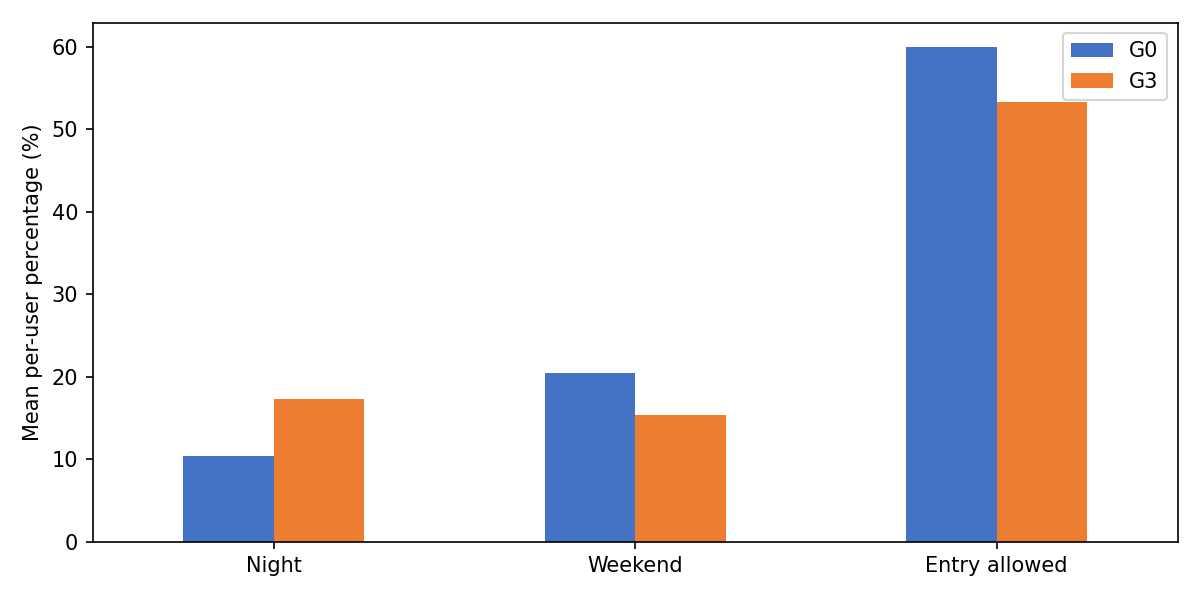

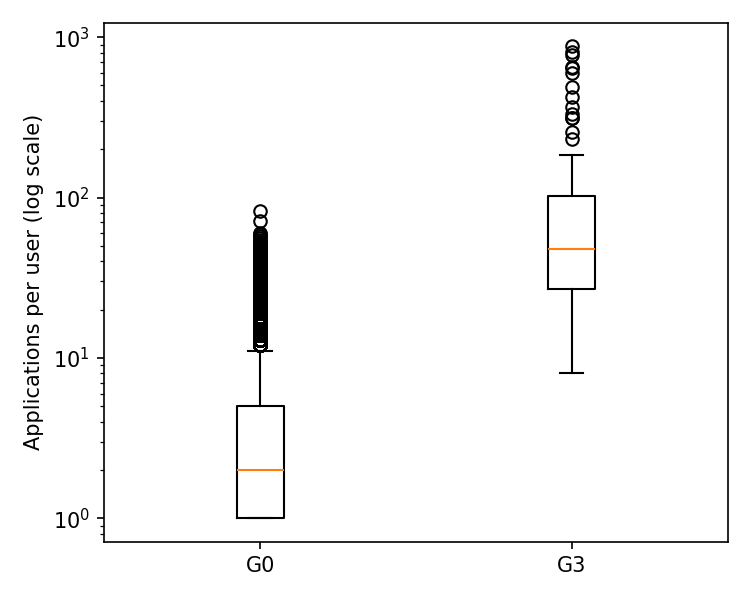

In [ ]:
application_rate_comparison = user_behavior_features.groupby('group_code')[
    ['night_application_pct', 'weekend_application_pct', 'entry_allowed_pct']
].mean().T
application_rate_comparison.index = ['Night', 'Weekend', 'Entry allowed']
application_rate_comparison.plot(
    kind='bar', figsize=(8, 4), color=['#4472C4', '#ED7D31']
)
plt.ylabel('Mean per-user percentage (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / '01_application_rates.png', dpi=150)
plt.show()

g0_application_counts = user_behavior_features.loc[
    user_behavior_features['group_code'].eq('G0'), 'application_count'
]
g3_application_counts = user_behavior_features.loc[
    user_behavior_features['group_code'].eq('G3'), 'application_count'
]
plt.figure(figsize=(5, 4))
plt.boxplot([g0_application_counts, g3_application_counts])
plt.xticks([1, 2], ['G0', 'G3'])
plt.yscale('log')
plt.ylabel('Applications per user (log scale)')
plt.tight_layout()
plt.savefig(output_dir / '02_application_counts.png', dpi=150)
plt.show()


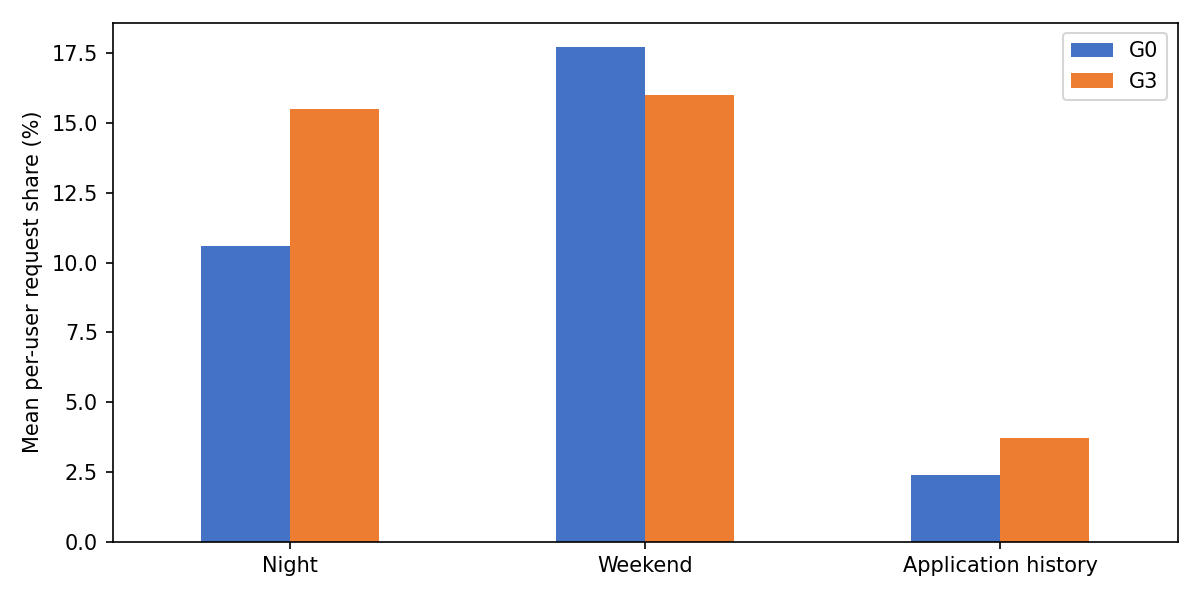

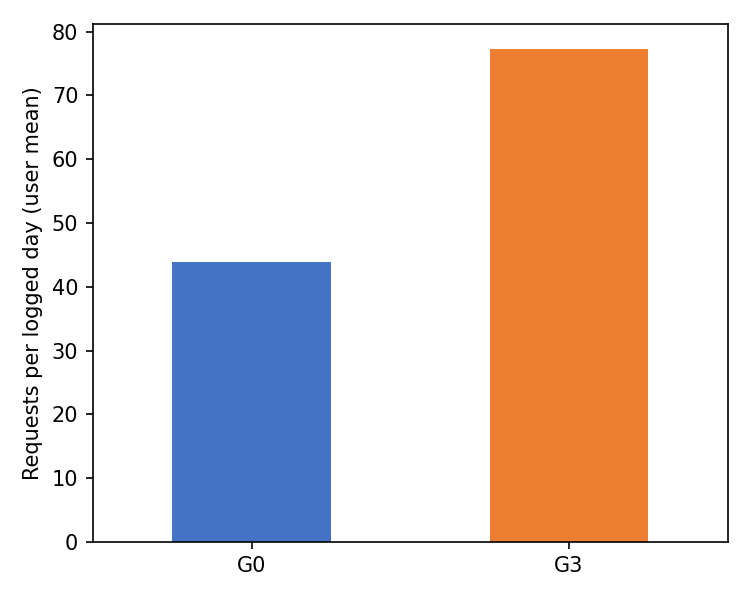

In [ ]:
log_rate_comparison = user_behavior_features.groupby('group_code')[
    ['night_log_pct', 'weekend_log_pct', 'history_request_pct']
].mean().T
log_rate_comparison.index = ['Night', 'Weekend', 'Application history']
log_rate_comparison.plot(
    kind='bar', figsize=(8, 4), color=['#4472C4', '#ED7D31']
)
plt.ylabel('Mean per-user request share (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / '03_log_request_shares.png', dpi=150)
plt.show()

user_behavior_features.groupby('group_code')['requests_per_log_day'].mean().plot(
    kind='bar', figsize=(5, 4), color=['#4472C4', '#ED7D31']
)
plt.ylabel('Requests per logged day (user mean)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / '04_log_requests_per_day.png', dpi=150)
plt.show()


## 10. 그룹 간 차이 검정

원본과 같은 Mann-Whitney U 검정을 사용한다. 유저별 값의 순위를 비교하는 검정이며, 평균 차이를 직접 검정하는 것은 아니다. 결측값을 제외한 G0과 G3를 비교한다.

지원 행동 세 변수와 로그 행동 네 변수는 각각 묶어서 검정한다. 한 묶음에서 여러 번 검정하므로 원본처럼 Bonferroni 보정을 적용한다. 지원 변수의 p값에는 3을, 로그 변수의 p값에는 4를 곱하고 최대 1로 제한한다.

- p_adjusted가 0.05 미만이면 해당 검정에서 그룹 차이가 나타났다고 본다.
- rank_effect_G3_G0는 순위 차이의 방향과 크기를 나타낸다. 양수면 G3 쪽 값이 더 높은 순위를 갖는 방향이고, 음수면 반대다.
- 평균, 중앙값, 순위 효과의 방향이 다를 수 있으므로 모두 같이 확인한다.

검정 결과만으로 실제 허수 여부나 행동의 원인을 확정할 수는 없다.


In [ ]:
test_metric_groups = {
    'application': [
        'night_application_pct', 'weekend_application_pct', 'entry_allowed_pct'
    ],
    'log': [
        'requests_per_log_day', 'night_log_pct',
        'weekend_log_pct', 'history_request_pct'
    ]
}
test_rows = []

for analysis_name, test_metrics in test_metric_groups.items():
    for metric in test_metrics:
        g0_values = user_behavior_features.loc[
            user_behavior_features['group_code'].eq('G0'), metric
        ].dropna()
        g3_values = user_behavior_features.loc[
            user_behavior_features['group_code'].eq('G3'), metric
        ].dropna()

        assert len(g0_values) >= 2 and len(g3_values) >= 2
        u_statistic, p_value = mannwhitneyu(
            g3_values, g0_values, alternative='two-sided', method='asymptotic'
        )
        rank_effect = 2 * u_statistic / (len(g3_values) * len(g0_values)) - 1
        p_adjusted = min(p_value * len(test_metrics), 1)

        test_rows.append({
            'analysis': analysis_name,
            'metric': metric,
            'G0_n': len(g0_values),
            'G3_n': len(g3_values),
            'G0_mean': g0_values.mean(),
            'G3_mean': g3_values.mean(),
            'G0_median': g0_values.median(),
            'G3_median': g3_values.median(),
            'mean_diff': g3_values.mean() - g0_values.mean(),
            'rank_effect_G3_G0': rank_effect,
            'p_value': p_value,
            'p_adjusted': p_adjusted,
            'significant': p_adjusted < 0.05
        })

group_tests = pd.DataFrame(test_rows)
display(group_tests)


,analysis,metric,G0_n,G3_n,G0_mean,G3_mean,G0_median,G3_median,mean_diff,rank_effect_G3_G0,p_value,p_adjusted,significant
0,application,night_application_pct,8362,104,10.445884,17.335617,0.000000,6.316489,6.889733,0.401584,8.902515e-23,2.670754e-22,True
1,application,weekend_application_pct,8362,104,20.473854,15.443119,0.000000,7.207792,-5.030735,0.163142,7.185305e-04,2.155591e-03,True
2,application,entry_allowed_pct,8293,104,59.972605,53.309280,66.666667,51.494869,-6.663325,-0.177839,1.261808e-03,3.785424e-03,True
3,log,requests_per_log_day,8362,104,43.888388,77.263502,34.618037,58.498875,33.375114,0.534766,6.168919e-21,2.467568e-20,True
4,log,night_log_pct,8362,104,10.604215,15.495006,3.468798,9.948754,4.890791,0.255074,6.275265e-06,2.510106e-05,True
5,log,weekend_log_pct,8362,104,17.704522,15.980870,10.582647,12.167907,-1.723652,0.032006,5.736972e-01,1.000000e+00,False
6,log,history_request_pct,8362,104,2.380219,3.713167,1.576967,3.023637,1.332948,0.235616,3.505821e-05,1.402328e-04,True


## 연도별 지원 행동 비교

2022년과 2023년의 기록을 나눠 같은 경향인지 확인한다. 먼저 유저별, 연도별 비율을 구하고 그 해에 지원한 유저의 그룹 평균을 계산한다.

그룹은 2년 자료로 이미 정해진 그룹을 그대로 사용한다. 해마다 새로 분류한 결과가 아니다. 연도별 참여 유저가 달라질 수 있으므로 해당 연도의 유저 수도 함께 저장한다.


In [ ]:
comparison_applications['year'] = (
    comparison_applications['application_at_kst'].dt.year
)
year_user_applications = comparison_applications.groupby(
    ['user_uuid', 'year']
).agg(
    night_application_pct=('night_application', 'mean'),
    weekend_application_pct=('weekend_application', 'mean'),
    entry_allowed_pct=('entry_allowed', 'mean')
).reset_index()
year_application_metrics = [
    'night_application_pct', 'weekend_application_pct', 'entry_allowed_pct'
]
year_user_applications[year_application_metrics] *= 100
year_user_applications = year_user_applications.merge(
    comparison_users[['user_uuid', 'group_code']],
    on='user_uuid', how='left', validate='many_to_one'
)
year_application_comparison = year_user_applications.groupby(
    ['year', 'group_code']
)[year_application_metrics].mean()
year_application_valid_counts = year_user_applications.groupby(
    ['year', 'group_code']
)[year_application_metrics].count()

display(year_application_comparison.round(3))
display(year_application_valid_counts)


night_application_pct  weekend_application_pct  entry_allowed_pct
year group_code                                                                   
2022 G0                          11.03                    14.35              60.06
     G3                          17.83                    13.86              60.15
2023 G0                           9.75                    25.83              59.32
     G3                          17.23                    17.83              48.89

night_application_pct  weekend_application_pct  entry_allowed_pct
year group_code                                                                   
2022 G0                           4753                     4753               4683
     G3                             70                       70                 70
2023 G0                           4369                     4369               4362
     G3                             79                       79                 79

## 연도별 로그 행동 비교

로그도 유저별, 연도별로 다시 집계한다. 활동일당 요청 수는 그 해의 요청 수를 그 해에 로그가 있었던 날짜 수로 나눈다. 로그가 없는 유저는 해당 연도의 비율 계산에 포함되지 않는다.


In [ ]:
clean_logs['year'] = clean_logs['log_at_kst'].dt.year
year_user_logs = clean_logs.groupby(
    ['user_uuid', 'year'], observed=True
).agg(
    log_request_count=('path', 'size'),
    log_active_days=('log_date', 'nunique'),
    history_request_count=('history_request', 'sum'),
    night_log_pct=('night_log', 'mean'),
    weekend_log_pct=('weekend_log', 'mean')
).reset_index()
year_user_logs[['night_log_pct', 'weekend_log_pct']] *= 100
year_user_logs['requests_per_log_day'] = (
    year_user_logs['log_request_count'] / year_user_logs['log_active_days']
)
year_user_logs['history_request_pct'] = (
    year_user_logs['history_request_count'] / year_user_logs['log_request_count'] * 100
)
year_user_logs = year_user_logs.merge(
    comparison_users[['user_uuid', 'group_code']],
    on='user_uuid', how='left', validate='many_to_one'
)
year_log_metrics = [
    'requests_per_log_day', 'night_log_pct',
    'weekend_log_pct', 'history_request_pct'
]
year_log_comparison = year_user_logs.groupby(
    ['year', 'group_code']
)[year_log_metrics].mean()
year_log_valid_counts = year_user_logs.groupby(
    ['year', 'group_code']
)[year_log_metrics].count()

display(year_log_comparison.round(3))
display(year_log_valid_counts)


requests_per_log_day  night_log_pct  weekend_log_pct  history_request_pct
year group_code                                                                           
2022 G0                        43.292         11.130           16.251                2.083
     G3                        72.174         16.298           15.315                3.640
2023 G0                        34.276         10.466           19.156                2.345
     G3                        69.048         15.160           18.130                3.037

## 최종 결과 저장과 통합

최종 유저별 결과는 user_behavior_features다. user_uuid가 중복되지 않으며 G0과 G3 유저 한 명당 한 행이다. 

비교표는 metric과 statistic을 일반 열로 바꿔 저장한다. statistic의 mean은 평균, median은 중앙값이다. 

In [ ]:
application_comparison_table = application_comparison.reset_index().rename(
    columns={'level_0': 'metric', 'level_1': 'statistic'}
)
log_comparison_table = log_comparison.reset_index().rename(
    columns={'level_0': 'metric', 'level_1': 'statistic'}
)

user_behavior_features.to_csv(
    output_dir / 'g0_g3_user_features.csv', index=False, encoding='utf-8-sig'
)
application_comparison_table.to_csv(
    output_dir / 'application_comparison.csv', index=False, encoding='utf-8-sig'
)
log_comparison_table.to_csv(
    output_dir / 'log_comparison.csv', index=False, encoding='utf-8-sig'
)
valid_user_counts.reset_index().to_csv(
    output_dir / 'valid_user_counts.csv', index=False, encoding='utf-8-sig'
)
group_coverage.reset_index().to_csv(
    output_dir / 'group_coverage.csv', index=False, encoding='utf-8-sig'
)
group_tests.to_csv(
    output_dir / 'group_tests.csv', index=False, encoding='utf-8-sig'
)
year_application_comparison.reset_index().to_csv(
    output_dir / 'year_application_comparison.csv', index=False, encoding='utf-8-sig'
)
year_application_valid_counts.reset_index().to_csv(
    output_dir / 'year_application_valid_counts.csv', index=False, encoding='utf-8-sig'
)
year_log_comparison.reset_index().to_csv(
    output_dir / 'year_log_comparison.csv', index=False, encoding='utf-8-sig'
)
year_log_valid_counts.reset_index().to_csv(
    output_dir / 'year_log_valid_counts.csv', index=False, encoding='utf-8-sig'
)
print('저장 위치:', output_dir.resolve())
print('최종 유저별 결과:', len(user_behavior_features), '행')




여기서 final_table은 다른 담당자의 점수를 이미 모아 둔 유저별 표다. 이 분석 결과는 추가 점수가 아니라 그룹 비교용 행동 변수다.

G1과 G2는 이번 비교 대상이 아니므로 전체 유저 표에 붙이면 이들의 행동 열은 결측값으로 남는다. 이 결측값을 0으로 채우면 활동이 없었다는 뜻으로 바뀌므로 그대로 둔다. 최종 점수표에 application_count 같은 이름이 이미 있으면 결합 전에 한쪽 열 이름을 바꾸거나 중복 열을 제외한다.

통합 노트북에 같은 기간의 comparison_applications, bookmarks, comparison_users가 이미 만들어져 있다면 4번 지원 집계부터 연결할 수 있다. 로그도 6번과 같은 필터와 중복 기준을 적용한 clean_logs가 있으면 7번부터 이어서 쓴다. 아래에서 필요한 열 이름과 한국시간 기준을 먼저 맞춰야 한다.

| 다음 분석에 넘길 표 | 필요한 열 |
|---|---|
| comparison_users | user_uuid, user_group, group_code |
| comparison_applications | application_uuid, user_uuid, job_uuid, application_at_kst, bookmark_at_kst, career_type_string |
| bookmarks | user_uuid, job_uuid, bookmark_at_kst |
| clean_logs | user_uuid, path, method, log_at_kst |
| 최종 연결 표 | user_behavior_features 또는 g0_g3_user_features.csv |

### 최종 변수 설명

퍼센트 변수는 0부터 100까지의 값이다. 요청 수와 활동 날짜 수는 분석 기간 전체를 기준으로 한다.

| 변수 | 계산하거나 나타내는 값 |
|---|---|
| application_count | 지원 ID의 개수 |
| unique_job_count | 지원한 고유 공고 수 |
| application_active_days | 한 번 이상 지원한 날짜 수 |
| applications_per_active_day | 지원 수 / 지원한 날짜 수 |
| median_application_gap_min | 연속된 지원 간격의 중앙값, 분 단위 |
| repeat_application_pct | (지원 수 - 고유 공고 수) / 지원 수 × 100 |
| bookmark_count | 기간 내 북마크 공고 수. 지원하지 않은 공고도 포함 |
| bookmark_before_application_pct | 같은 공고를 지원 시각 이전 또는 같은 시각에 북마크한 지원 비율 |
| night_application_pct | 00:00부터 05:59까지 지원한 비율 |
| weekend_application_pct | 토요일과 일요일에 지원한 비율 |
| entry_allowed_pct | 경력 조건을 확인할 수 있는 지원 중 신입 허용 공고에 지원한 비율 |
| has_observed_logs | 정제 조건에 맞는 로그가 한 건 이상 있었는지 |
| log_request_count | 정제된 로그 요청 수 |
| log_active_days | 정제된 로그가 발생한 날짜 수 |
| requests_per_log_day | 로그 요청 수 / 로그가 발생한 날짜 수 |
| detail_request_count | 공고 상세 경로의 GET 요청 수 |
| detail_request_pct | 공고 상세 GET 요청 수 / 로그 요청 수 × 100 |
| detail_requests_per_application | 기간 전체 공고 상세 GET 요청 수 / 지원 수 |
| history_request_count | 지원 내역 경로의 GET 요청 수 |
| history_request_pct | 지원 내역 GET 요청 수 / 로그 요청 수 × 100 |
| night_log_pct | 00:00부터 05:59까지 발생한 로그 비율 |
| weekend_log_pct | 토요일과 일요일에 발생한 로그 비율 |
| logs_per_application | 기간 전체 로그 요청 수 / 지원 수 |

## 분석 과정과 결과 정리

지원과 북마크를 한국시간 기준 2022년과 2023년으로 제한하고, 그룹표와 유저 범위가 같은지 먼저 확인했다. 공고 정보와 북마크를 지원 기록에 연결한 뒤 G0과 G3를 골랐다. 지원 행동은 유저별 건수와 비율로 계산하고, 로그는 기간, 응답 코드, 중복 조건을 적용한 뒤 같은 유저별 표에 붙였다. 이 표를 기준으로 평균과 중앙값, 유효 유저 수, 검정 결과와 연도별 결과를 확인했다.

G0은 8,362명, G3은 104명이다. G0의 지원은 37,563건, G3의 지원은 11,889건이다. 비교 대상 모두에서 정제 로그가 확인됐으며 G0은 9,274,514건, G3은 429,382건이다.

1. **지원량과 간격**: 유저당 평균 지원은 G0 4.49건, G3 114.32건이다. 지원 건수 중앙값도 2건과 47.5건으로 차이가 크다. 유저별 지원 간격의 중앙값을 다시 그룹 중앙값으로 비교하면 G0은 2,400.1분, G3은 2.425분이다. G3에서 지원이 더 자주 몰리는 경향을 확인할 수 있다. 다만 지원량과 간격은 그룹을 만든 지표와 연결되므로, 이 차이를 허수 여부의 독립적인 검증으로 보지는 않는다.

2. **새벽 지원과 신입 허용**: 새벽 지원 비율의 유저 평균은 G0 10.45%, G3 17.34%다. 신입 허용 공고 지원 비율은 G0 59.97%, G3 53.31%다. 두 변수는 보정한 검정에서도 차이가 나타났다. 신입 허용 비율은 공고 조건의 차이이며 지원자의 실제 경력을 설명하는 값은 아니다.

3. **주말 지원은 평균만으로 해석하지 않기**: 주말 지원 비율의 평균은 G0 20.47%, G3 15.44%지만 중앙값은 G0 0%, G3 약 7.21%다. 순위 효과도 G3가 높은 방향이다. 일부 큰 값이 평균에 영향을 주므로 'G3는 주말 지원이 더 적다'고 한 문장으로 정리하기 어렵다.

4. **로그 활동과 지원량의 관계**: 로그 활동일당 요청 수의 유저 평균은 G0 43.89건, G3 77.26건이다. 반면 지원 1건당 전체 로그 요청 수의 유저 평균은 G0 423.54건, G3 57.21건이고, 공고 상세 요청 수는 G0 26.95건, G3 5.14건이다. G3는 요청 자체도 많지만 지원량이 더 커서 지원 수로 나눈 값은 작다. 이 값만으로 공고를 충분히 읽었는지 판단할 수는 없다.

5. **로그의 시간대와 지원 내역 요청**: G3는 새벽 로그 비율과 지원 내역 요청 비율이 더 높고, 보정한 검정에서도 차이가 나타났다. 주말 로그 비율은 보정한 검정에서 차이가 확인되지 않았다.

6. **연도별 확인**: G3의 새벽 지원 비율과 로그 활동일당 요청 수는 두 해 모두 G0보다 높았다. 신입 허용 공고 지원 비율은 2022년에 거의 같았지만 2023년에는 G3가 더 낮았다. 전체 기간에서 보인 모든 차이가 두 해에 똑같이 나타나는 것은 아니다. 연도별 값은 고정된 그룹 안에서 그 해 활동한 유저를 비교한 결과다.
